# Unemployment Analysis with Python

## Objective

Analyze unemployment trends in India using exploratory data analysis and time-series visualization, with a focus on regional variations and the impact of the COVID-19 pandemic.

## 1. Import Required Libraries

In [98]:
# Data Manipulation
import numpy as np
import pandas as pd

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Date and Time Handling
from datetime import datetime

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

# Visualization Style
sns.set_theme(style="whitegrid")

print("All libraries imported successfully.")

All libraries imported successfully.


## 2. Dataset Loading

In [99]:
# Load the Dataset

df = pd.read_csv("../data/Unemployment in India.csv")

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [100]:
# Display the First Five Records

display(df.head())

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [101]:
# Dataset Shape

print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

Rows    : 768
Columns : 7


## 3. Data Cleaning and Preparation

In [102]:
# Dataset Information

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    str    
 1    Date                                     740 non-null    str    
 2    Frequency                                740 non-null    str    
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    str    
dtypes: float64(3), str(4)
memory usage: 42.1 KB


In [103]:
# Missing Values

display(df.isnull().sum())

Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64

In [104]:
# Duplicate Records

print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 27


In [105]:
# Rename Columns

df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(" ", "_")
)

display(df.columns)

Index(['region', 'date', 'frequency', 'estimated_unemployment_rate_(%)',
       'estimated_employed', 'estimated_labour_participation_rate_(%)',
       'area'],
      dtype='str')

In [106]:
# Preview Updated Columns

display(df.head())

,region,date,frequency,estimated_unemployment_rate_(%),estimated_employed,estimated_labour_participation_rate_(%),area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [107]:
# Convert Date Column

df["date"] = pd.to_datetime(df["date"])

print("Date conversion completed.")

Date conversion completed.


In [108]:
# Verify Data Types

display(df.dtypes)

region                                                str
date                                       datetime64[us]
frequency                                             str
estimated_unemployment_rate_(%)                   float64
estimated_employed                                float64
estimated_labour_participation_rate_(%)           float64
area                                                  str
dtype: object

In [109]:
# Statistical Summary

display(df.describe())

,date,estimated_unemployment_rate_(%),estimated_employed,estimated_labour_participation_rate_(%)
count,740,740.000000,7.400000e+02,740.000000
mean,2019-12-12 18:36:58.378378,11.787946,7.204460e+06,42.630122
min,2019-05-31 00:00:00,0.000000,4.942000e+04,13.330000
25%,2019-08-31 00:00:00,4.657500,1.190404e+06,38.062500
50%,2019-11-30 00:00:00,8.350000,4.744178e+06,41.160000
75%,2020-03-31 00:00:00,15.887500,1.127549e+07,45.505000
max,2020-06-30 00:00:00,76.740000,4.577751e+07,72.570000
std,NaN,10.721298,8.087988e+06,8.111094


### Observation

The dataset contains unemployment statistics across multiple Indian states and regions over time. After cleaning, the date column has been converted to a datetime format, enabling time-series analysis. The numerical features are suitable for exploratory analysis and visualization.

## 4. Exploratory Data Analysis

In [110]:
# Average Unemployment Rate by Region

region_avg = (
    df.groupby("region")["estimated_unemployment_rate_(%)"]
      .mean()
      .sort_values(ascending=False)
      .reset_index()
)

display(region_avg)

,region,estimated_unemployment_rate_(%)
0,Tripura,28.350357
1,Haryana,26.283214
2,Jharkhand,20.585000
3,Bihar,18.918214
4,Himachal Pradesh,18.540357
5,Delhi,16.495357
6,Jammu & Kashmir,16.188571
7,Chandigarh,15.991667
8,Rajasthan,14.058214
9,Uttar Pradesh,12.551429


### Observation

The table shows the average unemployment rate across different Indian states and union territories. Regions with higher average unemployment rates indicate comparatively weaker employment conditions during the observed period.

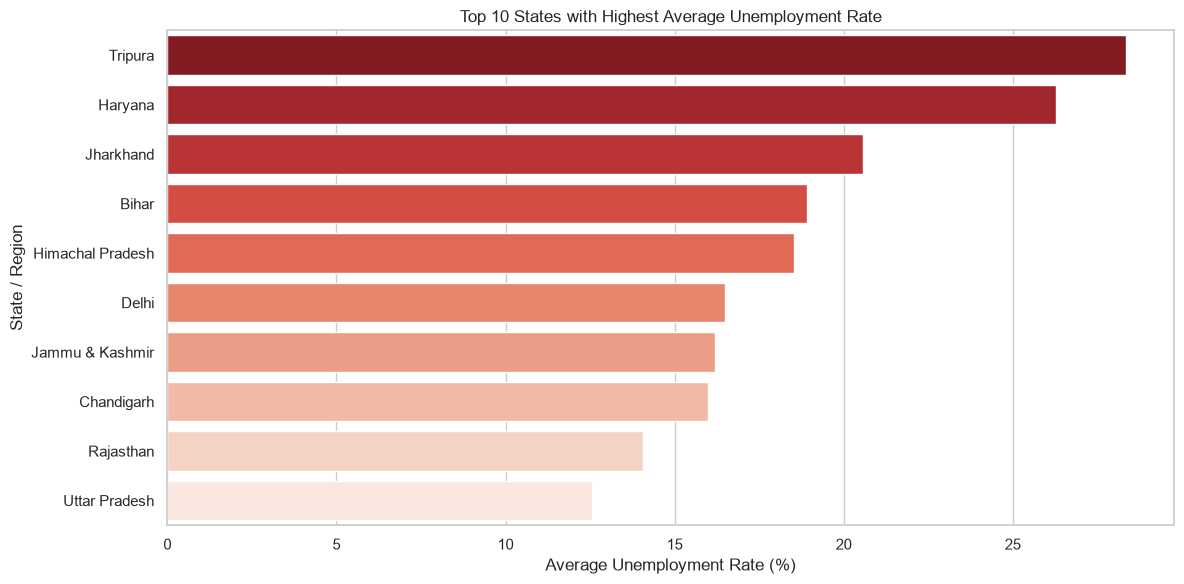

In [111]:
# Top 10 States by Average Unemployment Rate

top10 = region_avg.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10,
    x="estimated_unemployment_rate_(%)",
    y="region",
    hue="region",
    palette="Reds_r",
    legend=False
)

plt.title("Top 10 States with Highest Average Unemployment Rate")
plt.xlabel("Average Unemployment Rate (%)")
plt.ylabel("State / Region")

plt.tight_layout()

plt.savefig(
    "../outputs/images/top10_unemployment.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

The visualization highlights the ten states with the highest average unemployment rates. These regions experienced comparatively greater employment challenges and may require stronger policy interventions to improve labour market conditions.

## 5. Regional Analysis

In [112]:
# Create Year-Month Column

df["year_month"] = df["date"].dt.to_period("M").astype(str)

monthly_avg = (
    df.groupby("year_month")["estimated_unemployment_rate_(%)"]
      .mean()
      .reset_index()
)

display(monthly_avg)

,year_month,estimated_unemployment_rate_(%)
0,2019-05,8.874259
1,2019-06,9.303333
2,2019-07,9.033889
3,2019-08,9.637925
4,2019-09,9.051731
5,2019-10,9.900909
6,2019-11,9.868364
7,2019-12,9.497358
8,2020-01,9.950755
9,2020-02,9.964717


In [113]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=monthly_avg,
    x="month",
    y="estimated_unemployment_rate_(%)",
    marker="o"
)

plt.xticks(rotation=45)

plt.title("Average Monthly Unemployment Rate")

plt.xlabel("Month")
plt.ylabel("Average Unemployment Rate (%)")

plt.tight_layout()

plt.savefig(
    "../outputs/images/monthly_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

ValueError: Could not interpret value `month` for `x`. An entry with this name does not appear in `data`.

<Figure size 1200x600 with 0 Axes>

### Observation

The month-wise trend illustrates seasonal changes in unemployment across India. Peaks indicate periods of higher unemployment, while lower values suggest relatively improved employment conditions.

## 6. Time-Series Analysis

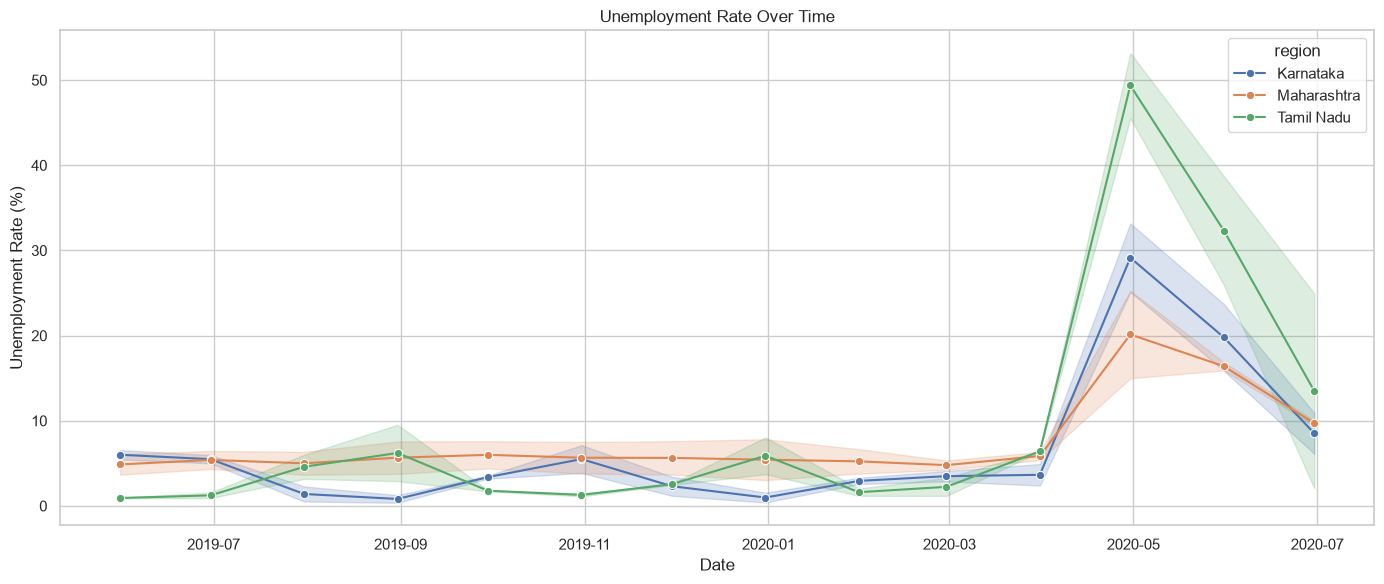

In [ ]:
major_states = [
    "Maharashtra",
    "Tamil Nadu",
    "Karnataka"
]

state_df = df[df["region"].isin(major_states)]

plt.figure(figsize=(14,6))

sns.lineplot(
    data=state_df,
    x="date",
    y="estimated_unemployment_rate_(%)",
    hue="region",
    marker="o"
)

plt.title("Unemployment Rate Over Time")

plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")

plt.tight_layout()

plt.savefig(
    "../outputs/images/time_series_states.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

The time-series visualization compares unemployment trends across three major states. Variations over time highlight how regional labour markets responded differently, particularly during periods affected by the COVID-19 pandemic.

## 7. COVID-19 Impact Analysis

In [ ]:
# Split Dataset into Pre-COVID and Post-COVID

covid_date = pd.Timestamp("2020-03-01")

pre_covid = df[df["date"] < covid_date]
post_covid = df[df["date"] >= covid_date]

print("Pre-COVID Records :", len(pre_covid))
print("Post-COVID Records:", len(post_covid))

Pre-COVID Records : 536
Post-COVID Records: 204


In [ ]:
# Compare Average Unemployment Rate

covid_comparison = pd.DataFrame({
    "Period": ["Pre-COVID", "Post-COVID"],
    "Average Unemployment Rate (%)": [
        pre_covid["estimated_unemployment_rate_(%)"].mean(),
        post_covid["estimated_unemployment_rate_(%)"].mean()
    ]
})

display(covid_comparison)

,Period,Average Unemployment Rate (%)
0,Pre-COVID,9.509534
1,Post-COVID,17.774363


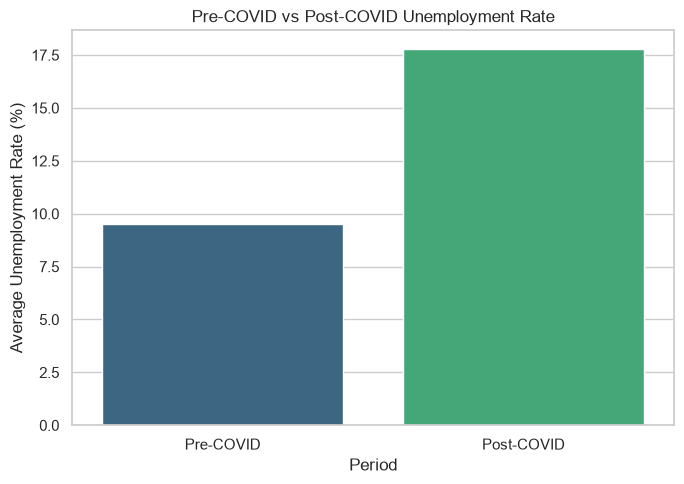

In [ ]:
plt.figure(figsize=(7,5))

sns.barplot(
    data=covid_comparison,
    x="Period",
    y="Average Unemployment Rate (%)",
    hue="Period",
    palette="viridis",
    legend=False
)

plt.title("Pre-COVID vs Post-COVID Unemployment Rate")

plt.tight_layout()

plt.savefig(
    "../outputs/images/covid_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

The comparison illustrates the effect of the COVID-19 pandemic on unemployment in India. A higher average unemployment rate during the post-COVID period indicates the disruption caused by lockdowns, reduced economic activity, and changes in labour market conditions.

## 8. Correlation Analysis

In [ ]:
# Correlation Matrix

correlation = df[
    [
        "estimated_unemployment_rate_(%)",
        "estimated_employed",
        "estimated_labour_participation_rate_(%)"
    ]
].corr()

display(correlation)

,estimated_unemployment_rate_(%),estimated_employed,estimated_labour_participation_rate_(%)
estimated_unemployment_rate_(%),1.000000,-0.222876,0.002558
estimated_employed,-0.222876,1.000000,0.011300
estimated_labour_participation_rate_(%),0.002558,0.011300,1.000000


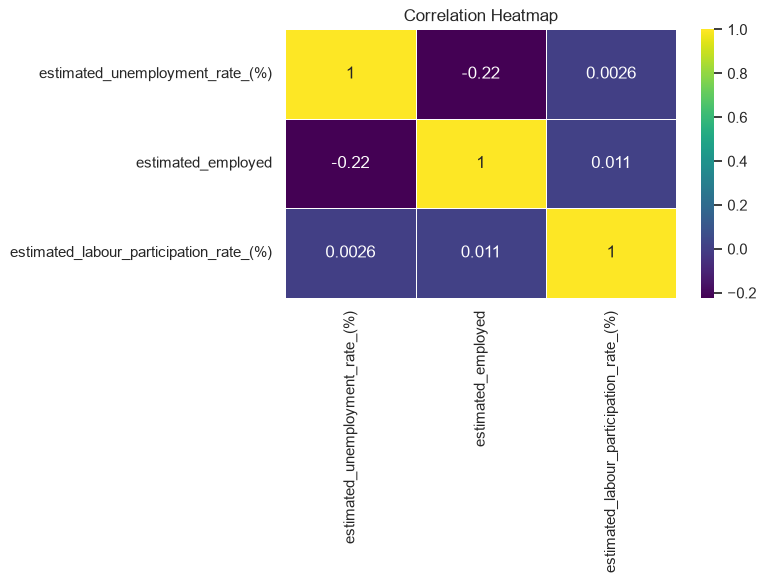

In [ ]:
plt.figure(figsize=(8,6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="viridis",
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.savefig(
    "../outputs/images/correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

The heatmap highlights the relationships between unemployment rate, employment level, and labour participation rate. Strong positive or negative correlations indicate how these economic indicators influence one another.

## Dataset Summary

In [ ]:
summary = pd.DataFrame({
    "Attribute": [
        "Total Records",
        "Total Features",
        "States / Regions",
        "Time Period",
        "Missing Values",
        "Analysis Type"
    ],
    "Value": [
        df.shape[0],
        df.shape[1],
        df["region"].nunique(),
        f"{df['date'].min().year}–{df['date'].max().year}",
        int(df.isnull().sum().sum()),
        "Exploratory Data Analysis & Time-Series Analysis"
    ]
})

display(summary)

,Attribute,Value
0,Total Records,768
1,Total Features,9
2,States / Regions,28
3,Time Period,2019–2020
4,Missing Values,252
5,Analysis Type,Exploratory Data Analysis & Time-Series Analysis


## 9. Key Insights

- Significant differences exist in unemployment rates across Indian states.
- Monthly unemployment trends reveal noticeable fluctuations over time.
- The COVID-19 pandemic was associated with an increase in unemployment levels.
- Employment and labour participation exhibit meaningful relationships with unemployment.
- Regional analysis helps identify states that may require focused employment interventions.

## 10. Conclusion

This project analyzed unemployment trends in India using exploratory data analysis and time-series visualization.

### Summary

- Cleaned and prepared the unemployment dataset.
- Explored regional and temporal unemployment patterns.
- Identified the states with the highest average unemployment rates.
- Examined unemployment trends across major states.
- Compared unemployment levels before and after the COVID-19 pandemic.
- Investigated correlations between unemployment, employment, and labour participation.

Overall, the analysis demonstrates how exploratory data analysis and visualization can uncover meaningful employment trends and support data-driven decision-making.